# LSTM

## Importing Relevent Libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from sklearn.impute import SimpleImputer
from math import sqrt
print("Import Complete")

Import Complete


## Asian Paints

## Fetching Historic Price and Training data

In [15]:
# Define the ticker symbol
ticker_symbol = 'ASIANPAINT.NS'

# Set the start and end dates for the historical data
start_date = '2021-01-01'
end_date = '2024-06-10'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Use only the 'Close' column
data = df[['Close']]

# Convert the dataframe to a numpy array
dataset = data.values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Create a training data set
train_data_len = int(np.ceil(len(dataset) * .95))

# Create the scaled training data set
train_data = scaled_data[0:train_data_len, :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed


Epoch 1/6
720/720 [==============================] - 10s 12ms/step - loss: 0.0139
Epoch 2/6
720/720 [==============================] - 9s 12ms/step - loss: 0.0080
Epoch 3/6
720/720 [==============================] - 9s 12ms/step - loss: 0.0051
Epoch 4/6
720/720 [==============================] - 9s 12ms/step - loss: 0.0052
Epoch 5/6
720/720 [==============================] - 9s 12ms/step - loss: 0.0050
Epoch 6/6
2/2 [==============================] - 0s 7ms/step
MAE: 19.313449766577744
MSE: 674.6807998894918
RMSE: 25.97461837813006
1/1 [==============================] - 0s 13ms/step


/var/folders/5_/dt8hhmsn2wbd_9pqy9vv5x4c0000gn/T/ipykernel_81037/1788578189.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions[:len(valid)]


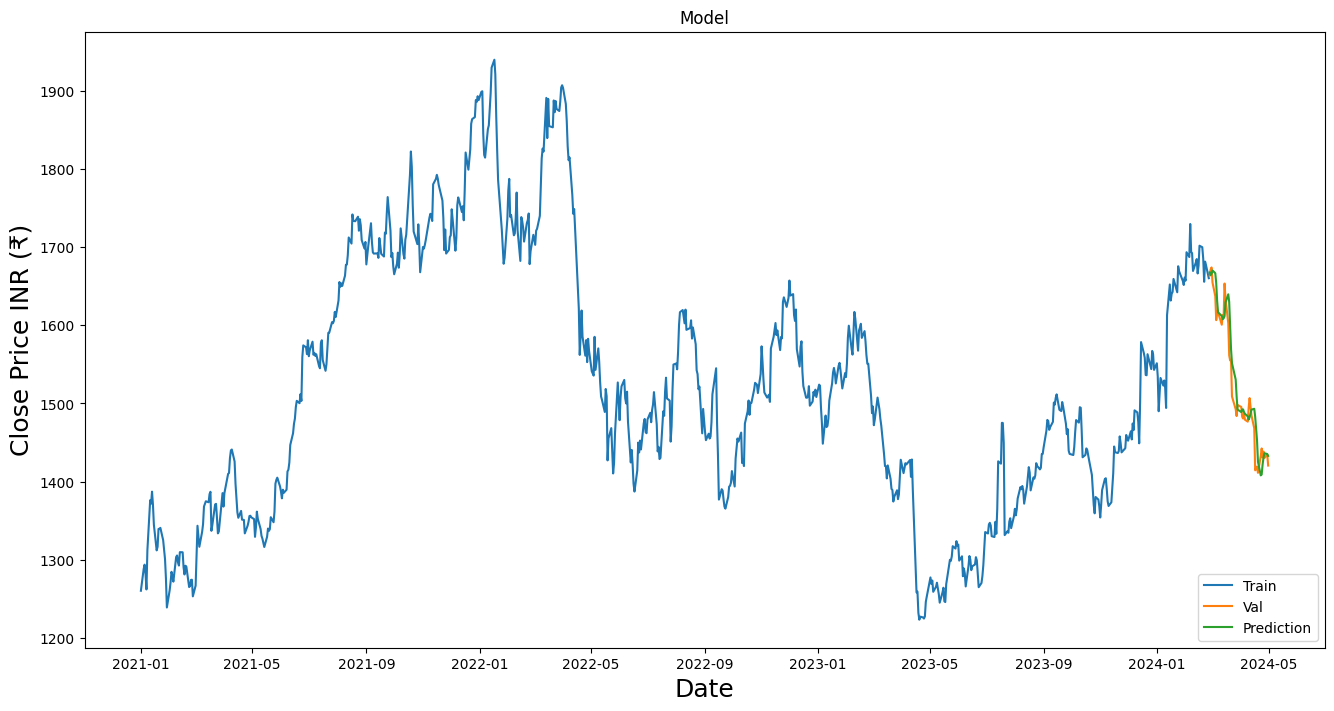

In [31]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt
from math import sqrt


ticker_symbol = 'INFY.NS'
start_date = '2021-01-01'
end_date = '2024-05-01'
df = yf.download(ticker_symbol, start=start_date, end=end_date)
data = df[['Close']]
dataset = data.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)
train_data_len = int(np.ceil(len(dataset) * .95))
train_data = scaled_data[0:train_data_len, :]
x_train = []
y_train = []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(x_train, y_train, batch_size=1, epochs=6)


test_data = scaled_data[train_data_len - 60:, :]


x_test = []
y_test = dataset[train_data_len:, :]  

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])


x_test = np.array(x_test)


x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)


mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")


future_days = 15
x_future = []
last_60_days = scaled_data[-60:, 0]

for i in range(future_days):
    x_temp = np.append(last_60_days, predictions[-1])[-60:]
    x_future.append(x_temp)
    x_temp = x_temp.reshape(1, 60, 1)  
    new_pred = model.predict(x_temp)
    predictions = np.append(predictions, new_pred)  

x_future = np.array(x_future)
x_future = np.reshape(x_future, (x_future.shape[0], x_future.shape[1], 1))
predicted_prices = model.predict(x_future)
predicted_prices = scaler.inverse_transform(predicted_prices)

# Plot the data
train = data[:train_data_len]
valid = data[train_data_len:]
valid['Predictions'] = predictions[:len(valid)]
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Prediction'], loc='lower right')


plt.savefig('stock_price_prediction_high_quality.png', dpi=400, bbox_inches='tight')

plt.show()


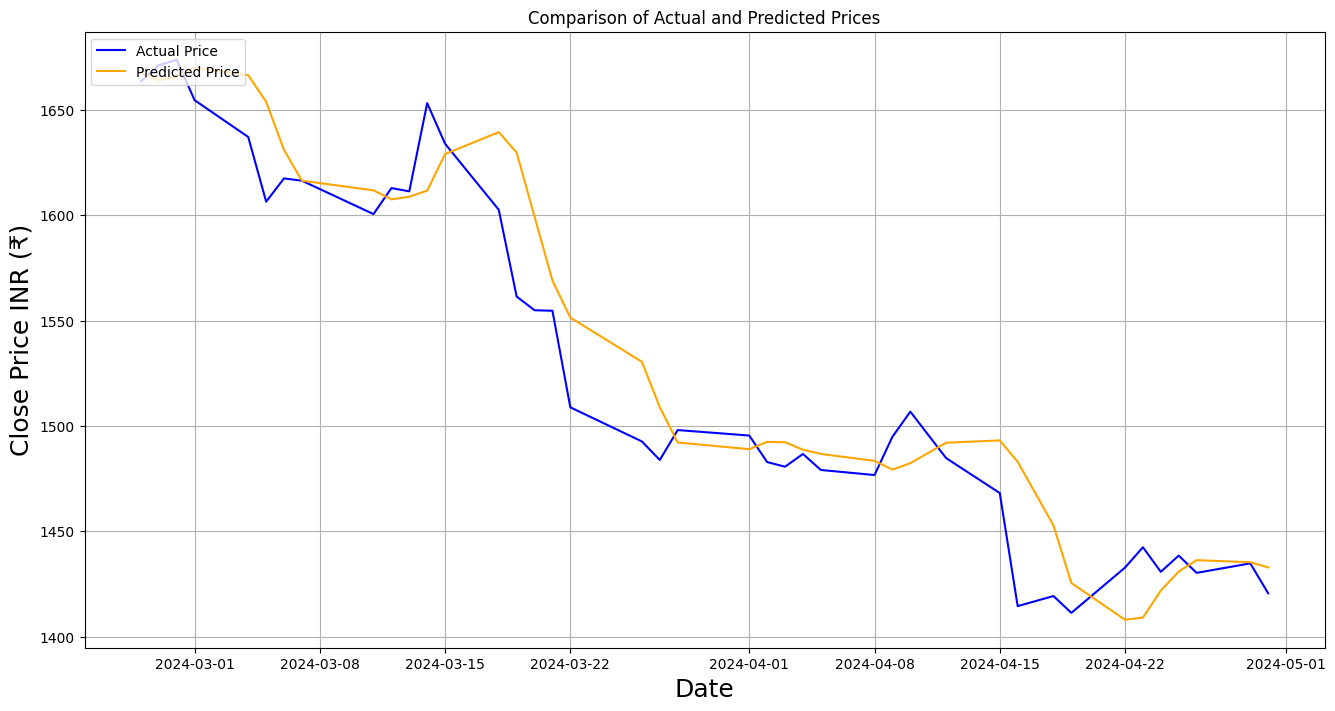

In [32]:
# Create a DataFrame for the validation (test) period
valid = pd.DataFrame(df['Close'][train_data_len:], index=df.index[train_data_len:])

# Include the predictions in the validation DataFrame
valid['Predictions'] = predictions[:len(valid)]  # Here predictions should match the length of the actual close prices in the validation set

# Plotting the actual prices and the predictions
plt.figure(figsize=(16,8))
plt.title('Comparison of Actual and Predicted Prices')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(valid['Close'], label='Actual Price', color='blue')
plt.plot(valid['Predictions'], label='Predicted Price', color='orange')
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig('infosys_lstm.png', dpi=400, bbox_inches='tight')
plt.show()


In [3]:
# Define function to calculate metrics
def calculate_metrics(ticker_symbol, start_date='2021-01-01', end_date='2024-05-01'):
    # Fetch historical data
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    data = df[['Close']]
    dataset = data.values

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create training and testing data
    train_data_len = int(np.ceil(len(dataset) * .95))
    train_data = scaled_data[0:train_data_len, :]

    x_train = []
    y_train = []

    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the LSTM model
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_train, y_train, batch_size=1, epochs=10)

    # Create the testing data set
    test_data = scaled_data[train_data_len - 60:, :]
    x_test = []
    y_test = dataset[train_data_len:, :]

    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Get model predictions
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    return mae, mse, rmse

# Define the ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']
results = []

# Calculate metrics for each stock
for ticker in ticker_symbols:
    mae, mse, rmse = calculate_metrics(ticker)
    results.append([ticker, mae, mse, rmse])

# Create a results dataframe
results_df = pd.DataFrame(results, columns=['Stock Name', 'MAE', 'MSE', 'RMSE'])

[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 21ms/step - loss: 0.0168
Epoch 2/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0078
Epoch 3/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0063
Epoch 4/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0052
Epoch 5/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0051
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0047
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0038
Epoch 8/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0040
Epoch 9/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0041
Epoch 10/10
2/2 [==============================] - 1s 10ms/step


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 20ms/step - loss: 0.0133
Epoch 2/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0078
Epoch 3/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0067
Epoch 4/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0051
Epoch 5/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0045
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0042
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0042
Epoch 8/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0041
Epoch 9/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0039
Epoch 10/10
2/2 [==============================] - 1s 9ms/step


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 20ms/step - loss: 0.0187
Epoch 2/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0085
Epoch 3/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0064
Epoch 4/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0053
Epoch 5/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0049
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0041
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0036
Epoch 8/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0041
Epoch 9/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0033
Epoch 10/10
2/2 [==============================] - 1s 9ms/step


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 20ms/step - loss: 0.0061
Epoch 2/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0064
Epoch 3/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0037
Epoch 4/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0028
Epoch 5/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0028
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0033
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0024
Epoch 8/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0020
Epoch 9/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0031
Epoch 10/10
2/2 [==============================] - 1s 8ms/step


ModuleNotFoundError: No module named 'ace_tools'

In [4]:
results_df

,Stock Name,MAE,MSE,RMSE
0,HINDUNILVR.NS,25.108744,1032.985502,32.140092
1,INFY.NS,16.415185,444.624627,21.086124
2,ASIANPAINT.NS,69.458568,5637.554328,75.083649
3,HEROMOTOCO.NS,86.804902,11034.324843,105.044395


# GRU

[*********************100%%**********************]  1 of 1 completed


Epoch 1/7
720/720 [==============================] - 10s 12ms/step - loss: 0.0143
Epoch 2/7
720/720 [==============================] - 8s 12ms/step - loss: 0.0064
Epoch 3/7
720/720 [==============================] - 8s 12ms/step - loss: 0.0042
Epoch 4/7
720/720 [==============================] - 8s 11ms/step - loss: 0.0037
Epoch 5/7
720/720 [==============================] - 8s 12ms/step - loss: 0.0037
Epoch 6/7
720/720 [==============================] - 8s 11ms/step - loss: 0.0037
Epoch 7/7
2/2 [==============================] - 0s 6ms/step
MAE: 22.21898223132622
MSE: 724.1187917764594
RMSE: 26.909455434409285
1/1 [==============================] - 0s 13ms/step


/var/folders/5_/dt8hhmsn2wbd_9pqy9vv5x4c0000gn/T/ipykernel_1287/454302551.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions[:len(valid)]


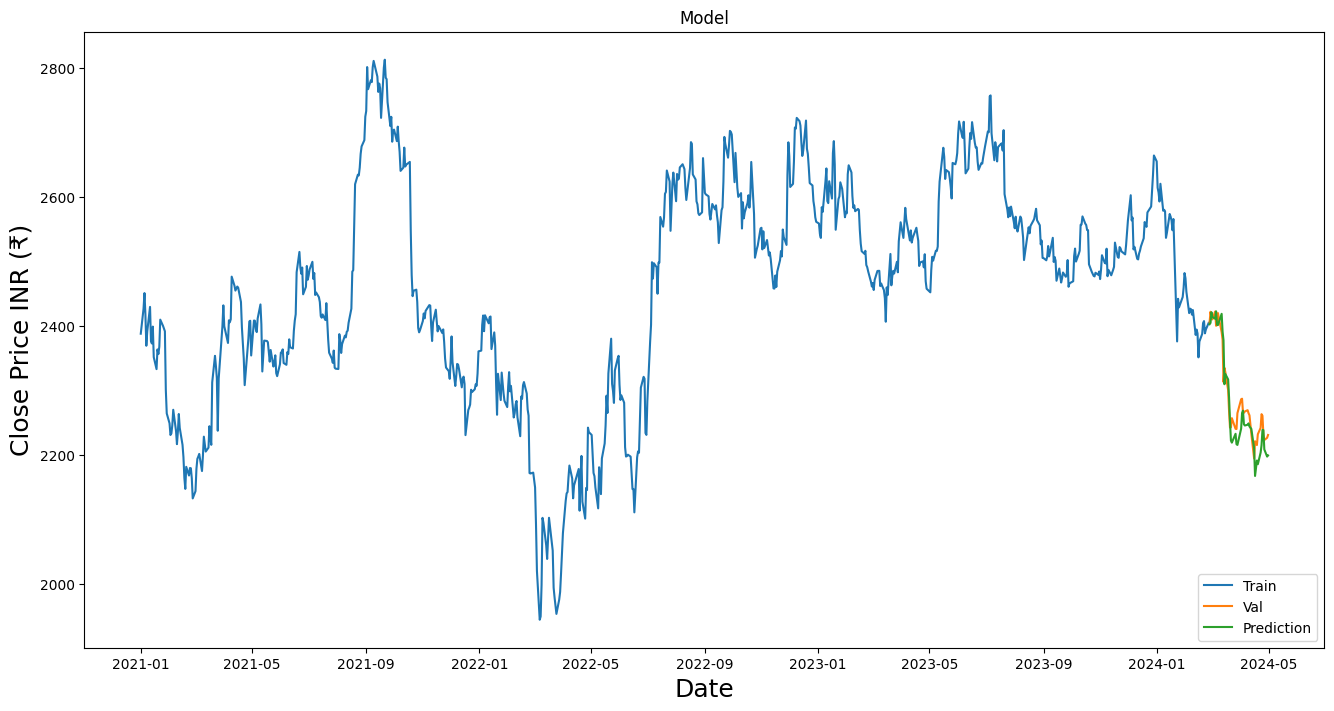

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout
import matplotlib.pyplot as plt
from math import sqrt


ticker_symbol = 'HINDUNILVR.NS'


start_date = '2021-01-01'
end_date = '2024-05-01'


df = yf.download(ticker_symbol, start=start_date, end=end_date)


data = df[['Close']]


dataset = data.values


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)


train_data_len = int(np.ceil(len(dataset) * .95))


train_data = scaled_data[0:train_data_len, :]


x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])


x_train, y_train = np.array(x_train), np.array(y_train)


x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


model = Sequential([
    GRU(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    GRU(50, return_sequences=True),
    Dropout(0.2),
    GRU(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])


model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(x_train, y_train, batch_size=1, epochs=7)


test_data = scaled_data[train_data_len - 60:, :]


x_test = []
y_test = dataset[train_data_len:, :]  

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])


x_test = np.array(x_test)


x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))


predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)


mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Extend the model to predict the next 15 days
future_days = 15
x_future = []
last_60_days = scaled_data[-60:, 0]

for i in range(future_days):
    x_temp = np.append(last_60_days, predictions[-1])[-60:]
    x_future.append(x_temp)
    x_temp = x_temp.reshape(1, 60, 1)  # Reshape for the model input
    new_pred = model.predict(x_temp)
    predictions = np.append(predictions, new_pred)  # Append the new prediction to update the sequence

x_future = np.array(x_future)
x_future = np.reshape(x_future, (x_future.shape[0], x_future.shape[1], 1))
predicted_prices = model.predict(x_future)
predicted_prices = scaler.inverse_transform(predicted_prices)

# Plot the data
train = data[:train_data_len]
valid = data[train_data_len:]
valid['Predictions'] = predictions[:len(valid)]
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Prediction'], loc='lower right')

# Save the figure in high resolution
plt.savefig('hul_gru_full.png', dpi=400, bbox_inches='tight')

plt.show()


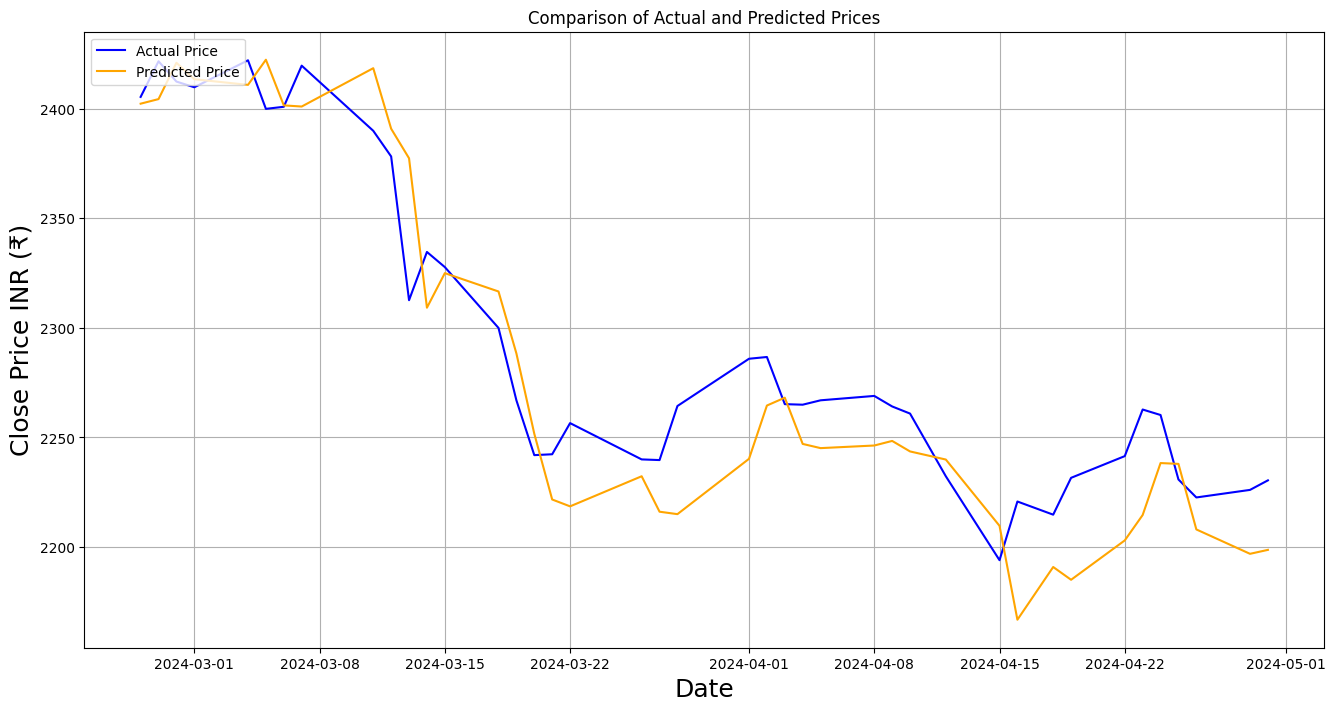

In [5]:
# Create a DataFrame for the validation (test) period
valid = pd.DataFrame(df['Close'][train_data_len:], index=df.index[train_data_len:])

# Include the predictions in the validation DataFrame
valid['Predictions'] = predictions[:len(valid)]  # Here predictions should match the length of the actual close prices in the validation set

# Plotting the actual prices and the predictions
plt.figure(figsize=(16,8))
plt.title('Comparison of Actual and Predicted Prices')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(valid['Close'], label='Actual Price', color='blue')
plt.plot(valid['Predictions'], label='Predicted Price', color='orange')
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig('hul_gru.png', dpi=400, bbox_inches='tight')
plt.show()

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

# Define function to calculate metrics
def calculate_metrics(ticker_symbol, start_date='2021-01-01', end_date='2024-05-01'):
    # Fetch historical data
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    data = df[['Close']]
    dataset = data.values

    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create training and testing data
    train_data_len = int(np.ceil(len(dataset) * .95))
    train_data = scaled_data[0:train_data_len, :]

    x_train = []
    y_train = []

    for i in range(60, len(train_data)):
        x_train.append(train_data[i-60:i, 0])
        y_train.append(train_data[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

    # Build the GRU model
    model = Sequential([
        GRU(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
        Dropout(0.2),
        GRU(50, return_sequences=True),
        Dropout(0.2),
        GRU(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x_train, y_train, batch_size=1, epochs=10)

    # Create the testing data set
    test_data = scaled_data[train_data_len - 60:, :]
    x_test = []
    y_test = dataset[train_data_len:, :]

    for i in range(60, len(test_data)):
        x_test.append(test_data[i-60:i, 0])

    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

    # Get model predictions
    predictions = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions)

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    return mae, mse, rmse

# Define the ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']
results = []

# Calculate metrics for each stock
for ticker in ticker_symbols:
    mae, mse, rmse = calculate_metrics(ticker)
    results.append([ticker, mae, mse, rmse])

# Create a results dataframe
results_df = pd.DataFrame(results, columns=['Stock Name', 'MAE', 'MSE', 'RMSE'])
results_df


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 20ms/step - loss: 0.0121
Epoch 2/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0052
Epoch 3/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0040
Epoch 4/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0034
Epoch 5/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0042
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0031
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0037
Epoch 8/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0037
Epoch 9/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0028
Epoch 10/10
2/2 [==============================] - 1s 8ms/step


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 20ms/step - loss: 0.0093
Epoch 2/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0049
Epoch 3/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0046
Epoch 4/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0044
Epoch 5/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0032
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0034
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0033
Epoch 8/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0038
Epoch 9/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0030
Epoch 10/10
2/2 [==============================] - 1s 8ms/step


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 16s 20ms/step - loss: 0.0121
Epoch 2/10
720/720 [==============================] - 14s 20ms/step - loss: 0.0058
Epoch 3/10
720/720 [==============================] - 14s 20ms/step - loss: 0.0040
Epoch 4/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0034
Epoch 5/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0030
Epoch 6/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0031
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0029
Epoch 8/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0032
Epoch 9/10
720/720 [==============================] - 14s 20ms/step - loss: 0.0031
Epoch 10/10
2/2 [==============================] - 1s 8ms/step


[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
720/720 [==============================] - 17s 20ms/step - loss: 0.0052
Epoch 2/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0034
Epoch 3/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0026
Epoch 4/10
720/720 [==============================] - 14s 20ms/step - loss: 0.0028
Epoch 5/10
720/720 [==============================] - 14s 20ms/step - loss: 0.0027
Epoch 6/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0042
Epoch 7/10
720/720 [==============================] - 15s 21ms/step - loss: 0.0021
Epoch 8/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0028
Epoch 9/10
720/720 [==============================] - 15s 20ms/step - loss: 0.0020
Epoch 10/10
2/2 [==============================] - 1s 8ms/step


,Stock Name,MAE,MSE,RMSE
0,HINDUNILVR.NS,19.895282,555.936185,23.578299
1,INFY.NS,18.943219,573.890554,23.956013
2,ASIANPAINT.NS,62.751596,4497.768641,67.065406
3,HEROMOTOCO.NS,160.005705,32995.124954,181.645603


# ARIMA

In [9]:
# Importing Relevent Libraries
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
print("Import Complete")

Import Complete


[*********************100%%**********************]  1 of 1 completed


Best ARIMA order for HINDUNILVR.NS: (2, 1, 4)


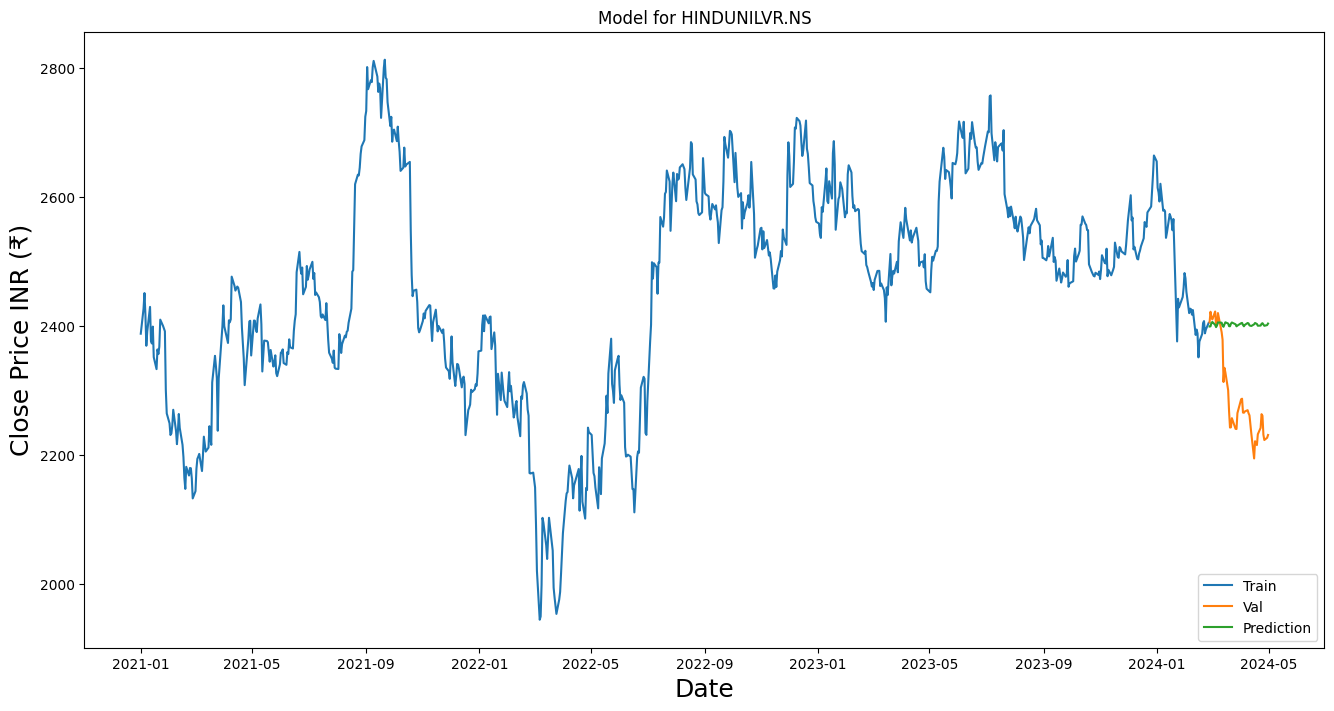

[*********************100%%**********************]  1 of 1 completed


Best ARIMA order for INFY.NS: (2, 2, 5)


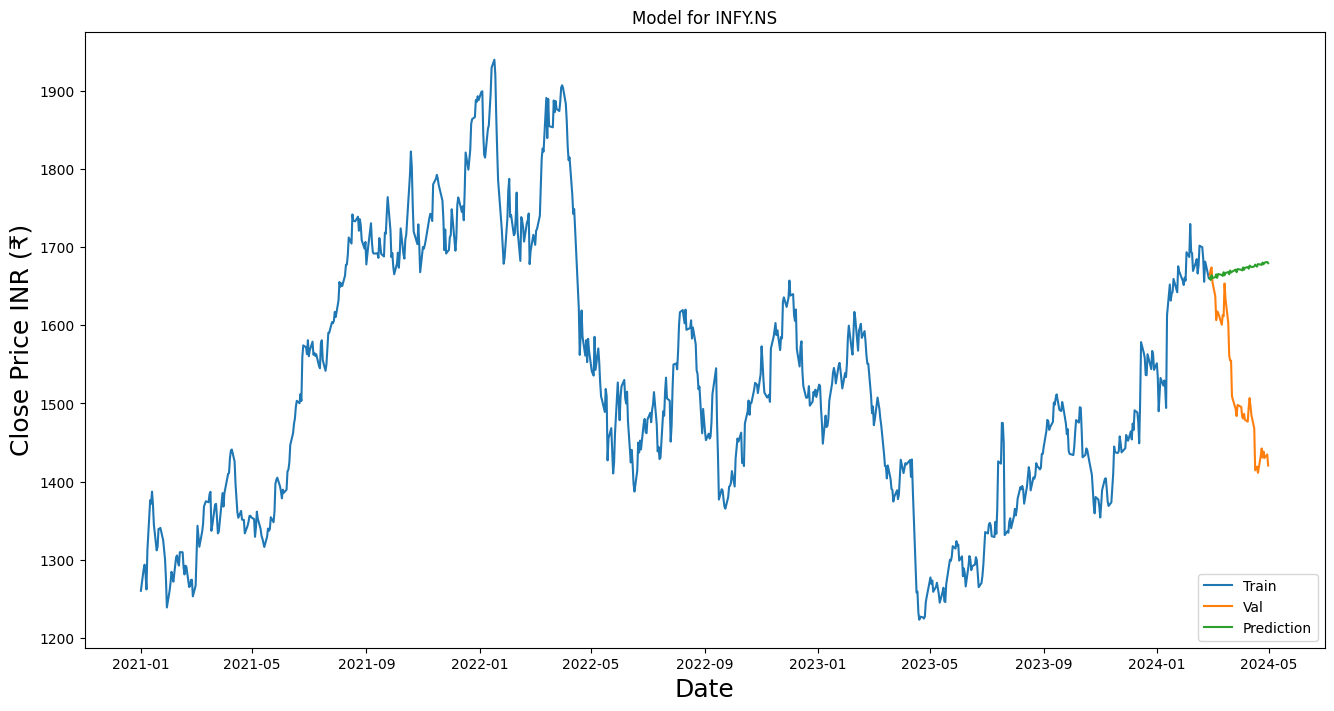

[*********************100%%**********************]  1 of 1 completed


Best ARIMA order for ASIANPAINT.NS: (3, 2, 3)


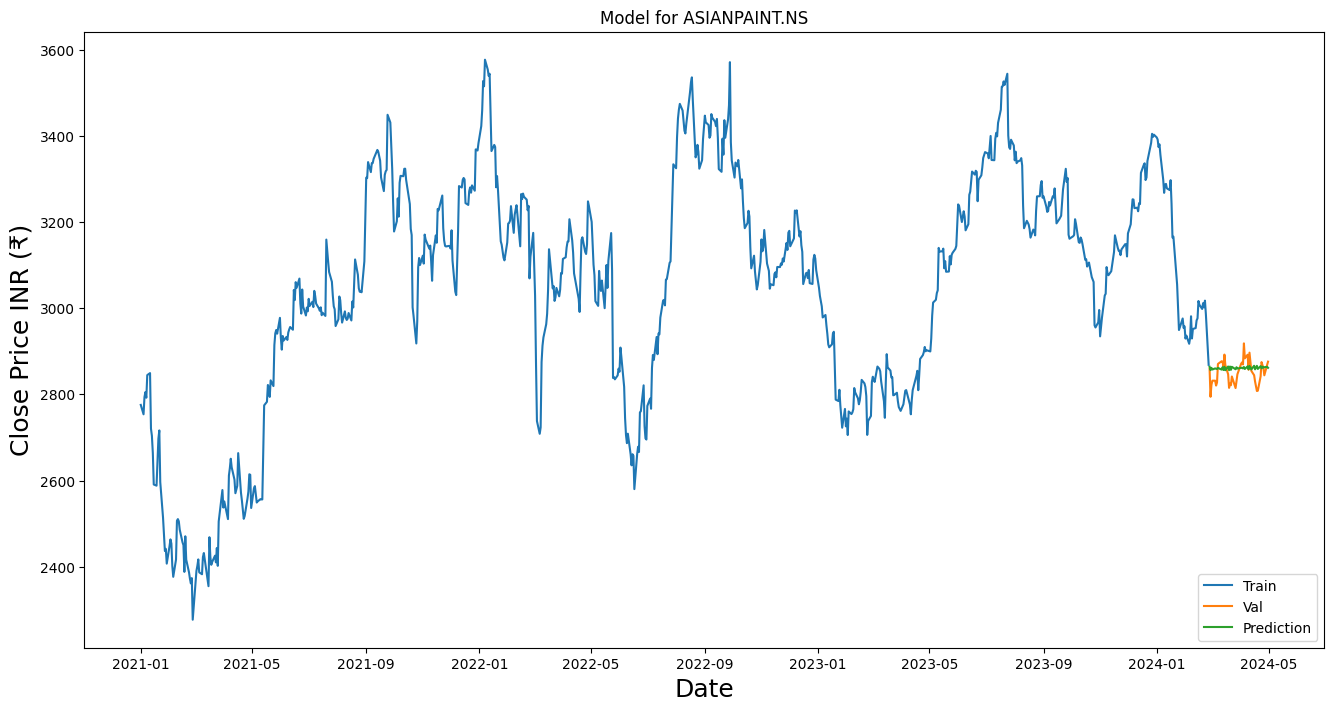

[*********************100%%**********************]  1 of 1 completed


Best ARIMA order for HEROMOTOCO.NS: (4, 1, 5)


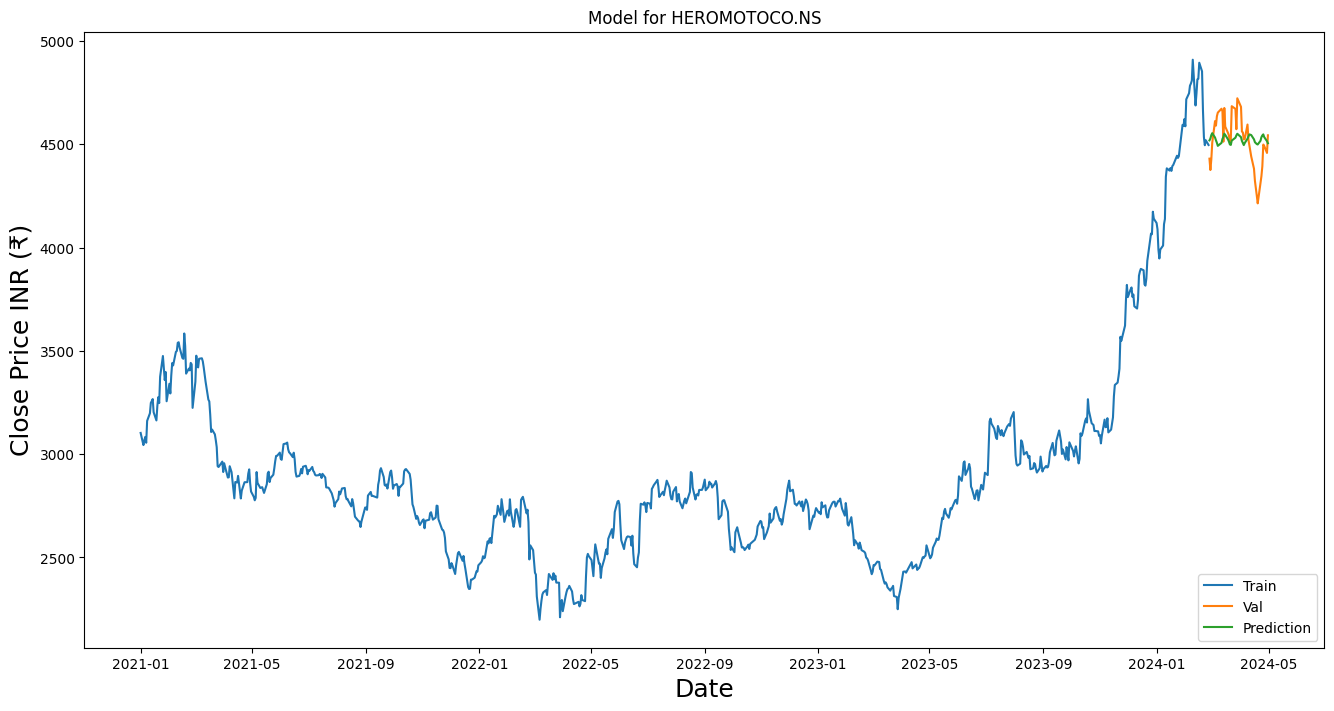

      Stock Name         MAE           MSE        RMSE
0  HINDUNILVR.NS  112.467609  16703.052020  129.240288
1        INFY.NS  143.843874  28415.919190  168.570220
2  ASIANPAINT.NS   23.746952    822.330453   28.676305
3  HEROMOTOCO.NS   98.954200  14551.615122  120.630076


In [7]:
def best_arima_params(train_data):
    p = range(0, 6)
    d = range(0, 3)
    q = range(0, 6)
    best_aic = float("inf")
    best_order = None
    for i in p:
        for j in d:
            for k in q:
                try:
                    model = ARIMA(train_data, order=(i, j, k))
                    model_fit = model.fit()
                    aic = model_fit.aic
                    if aic < best_aic:
                        best_aic = aic
                        best_order = (i, j, k)
                except:
                    continue
    return best_order


def calculate_arima_metrics(ticker_symbol, start_date='2021-01-01', end_date='2024-05-01'):
   
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    data = df[['Close']]
    dataset = data.values

  
    train_data_len = int(np.ceil(len(dataset) * .95))
    train_data = dataset[:train_data_len]
    test_data = dataset[train_data_len:]

    best_order = best_arima_params(train_data)
    print(f"Best ARIMA order for {ticker_symbol}: {best_order}")

    model = ARIMA(train_data, order=best_order)
    model_fit = model.fit()

    predictions = model_fit.forecast(steps=len(test_data))


    mae = mean_absolute_error(test_data, predictions)
    mse = mean_squared_error(test_data, predictions)
    rmse = np.sqrt(mse)


    train = pd.DataFrame(train_data, index=df.index[:train_data_len], columns=['Close'])
    valid = pd.DataFrame(test_data, index=df.index[train_data_len:], columns=['Close'])
    valid['Predictions'] = predictions
    plt.figure(figsize=(16,8))
    plt.title(f'Model for {ticker_symbol}')
    plt.xlabel('Date', fontsize=18)
    plt.ylabel('Close Price INR (₹)', fontsize=18)
    plt.plot(train['Close'])
    plt.plot(valid[['Close', 'Predictions']])
    plt.legend(['Train', 'Val', 'Prediction'], loc='lower right')

    
    plt.savefig(f'{ticker_symbol}_arima.png', dpi=400, bbox_inches='tight')
    plt.show()

    return mae, mse, rmse


ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']
results = []


for ticker in ticker_symbols:
    mae, mse, rmse = calculate_arima_metrics(ticker)
    results.append([ticker, mae, mse, rmse])


results_df = pd.DataFrame(results, columns=['Stock Name', 'MAE', 'MSE', 'RMSE'])
results_df


In [8]:
results_df

,Stock Name,MAE,MSE,RMSE
0,HINDUNILVR.NS,112.467609,16703.052020,129.240288
1,INFY.NS,143.843874,28415.919190,168.570220
2,ASIANPAINT.NS,23.746952,822.330453,28.676305
3,HEROMOTOCO.NS,98.954200,14551.615122,120.630076


# Future Prediction

[*********************100%%**********************]  1 of 1 completed


Epoch 1/50
720/720 [==============================] - 17s 21ms/step - loss: 0.0193
Epoch 2/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0088
Epoch 3/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0062
Epoch 4/50
720/720 [==============================] - 16s 22ms/step - loss: 0.0052
Epoch 5/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0044
Epoch 6/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0043
Epoch 7/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0040
Epoch 8/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0032
Epoch 9/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0033
Epoch 10/50
720/720 [==============================] - 16s 22ms/step - loss: 0.0030
Epoch 11/50
720/720 [==============================] - 16s 22ms/step - loss: 0.0027
Epoch 12/50
720/720 [==============================] - 15s 21ms/step - loss: 0.0026
E

/var/folders/5_/dt8hhmsn2wbd_9pqy9vv5x4c0000gn/T/ipykernel_6679/4155532437.py:106: FutureWarning: Argument `closed` is deprecated in favor of `inclusive`.
  future_dates = pd.date_range(start=last_date, periods=future_days + 1, closed='right')


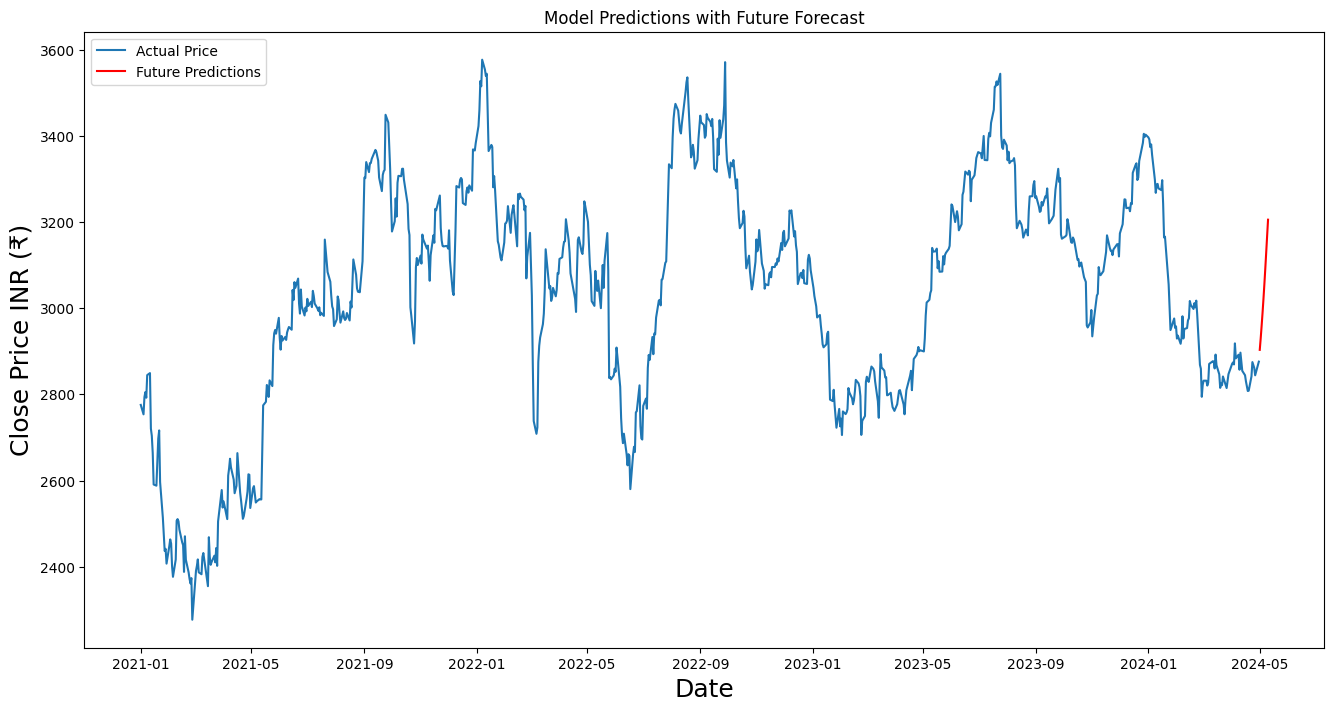

In [7]:
# Define the ticker symbol
ticker_symbol = 'ASIANPAINT.NS'

# Set the start and end dates for the historical data
start_date = '2021-01-01'
end_date = '2024-05-01'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Use only the 'Close' column
data = df[['Close']]

# Convert the dataframe to a numpy array
dataset = data.values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Create a training data set
train_data_len = int(np.ceil(len(dataset) * .95))

# Create the scaled training data set
train_data = scaled_data[0:train_data_len, :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for the LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build the LSTM model with additional layers
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=5)

# Create the testing data set
test_data = scaled_data[train_data_len - 60: , :]

# Create the data sets x_test
x_test = []
y_test = dataset[train_data_len:, 0]  # make sure to capture the actual test values for evaluation
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array and reshape
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the model predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Calculate the MSE and MAE
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

# Print the MSE and MAE
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Extend the model to predict the next 10 trading days
future_days = 10
x_future = scaled_data[-60:, 0].reshape(1, 60, 1)  # Starting from the last 60 days
predicted_future_prices = []

for i in range(future_days):
    new_pred = model.predict(x_future)
    predicted_future_prices.append(scaler.inverse_transform(new_pred)[0, 0])
    # Update x_future to include the new prediction
    x_future = np.append(x_future[:, 1:, :], new_pred).reshape(1, 60, 1)

# Generate dates for the future predictions
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_days + 1, closed='right')

# Prepare DataFrame to plot
future_df = pd.DataFrame(data=predicted_future_prices, index=future_dates, columns=['Future Predictions'])

# Plot the data including future predictions
plt.figure(figsize=(16,8))
plt.title('Model Predictions with Future Forecast')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(data['Close'], label='Actual Price')
plt.plot(future_df['Future Predictions'], label='Future Predictions', color='red')
plt.legend(loc='upper left')
plt.show()

[*********************100%%**********************]  1 of 1 completed


Epoch 1/2
2854/2854 [==============================] - 315s 110ms/step - loss: 0.0041
Epoch 2/2
6/6 [==============================] - 1s 58ms/step
Mean Squared Error: 9700.32
Mean Absolute Error: 76.45
1/1 [==============================] - 0s 32ms/step


/var/folders/5_/dt8hhmsn2wbd_9pqy9vv5x4c0000gn/T/ipykernel_52699/3294453390.py:107: FutureWarning: Argument `closed` is deprecated in favor of `inclusive`.
  future_dates = pd.date_range(start=last_date, periods=future_days + 1, closed='right')


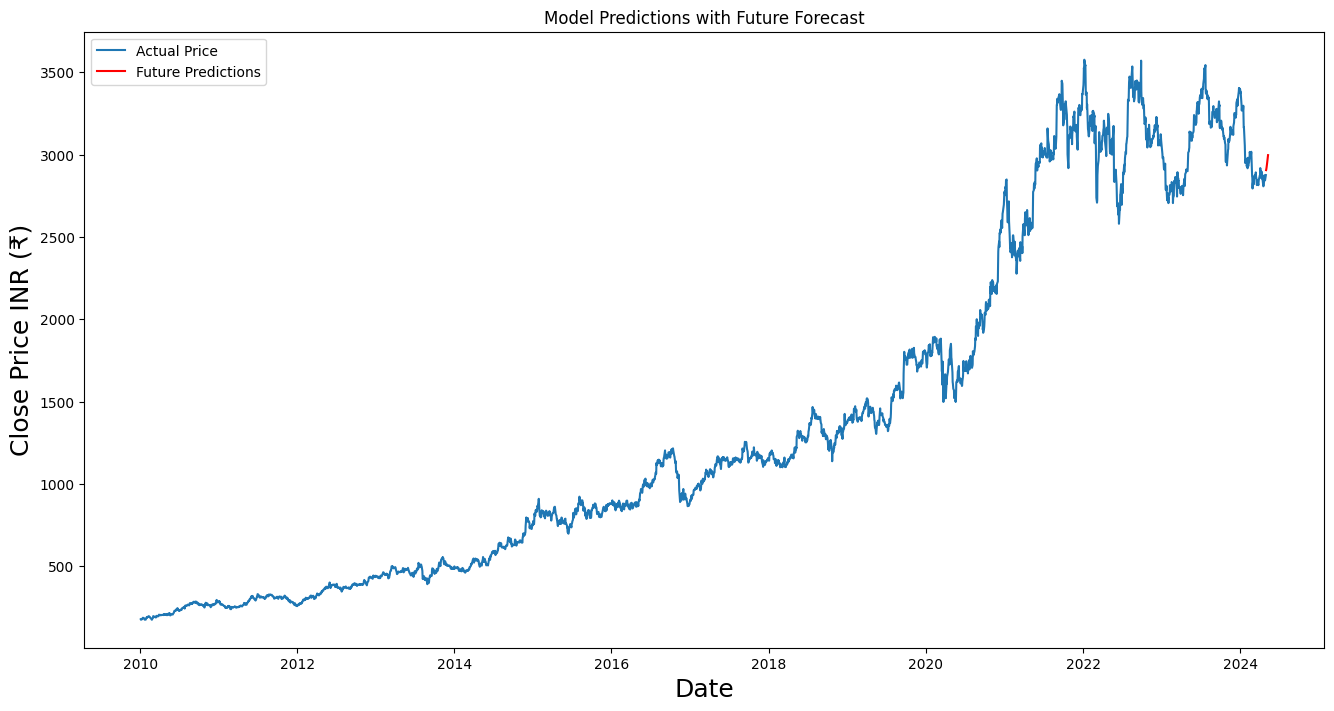

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Define the ticker symbol
ticker_symbol = 'ASIANPAINT.NS'

# Set the start and end dates for the historical data
start_date = '2010-01-01'
end_date = '2024-05-01'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Use only the 'Close' column
data = df[['Close']]

# Convert the dataframe to a numpy array
dataset = data.values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Create a training data set
train_data_len = int(np.ceil(len(dataset) * .95))

# Create the scaled training data set
train_data = scaled_data[0:train_data_len, :]

# Split the data into x_train and y_train data sets
x_train = []
y_train = []

# Using the last 2 years, approximately 2*252 = 504 trading days
for i in range(504, len(train_data)):
    x_train.append(train_data[i-504:i, 0])
    y_train.append(train_data[i, 0])

# Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for the LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build the LSTM model with additional layers
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=2)

# Create the testing data set
test_data = scaled_data[train_data_len - 504:, :]

# Create the data sets x_test
x_test = []
y_test = dataset[train_data_len:, 0]  # make sure to capture the actual test values for evaluation
for i in range(504, len(test_data)):
    x_test.append(test_data[i-504:i, 0])

# Convert the data to a numpy array and reshape
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the model predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Calculate the MSE and MAE
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

# Print the MSE and MAE
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Extend the model to predict the next 10 trading days
future_days = 10
x_future = scaled_data[-504:, 0].reshape(1, 504, 1)  # Starting from the last 504 days
predicted_future_prices = []

for i in range(future_days):
    new_pred = model.predict(x_future)
    predicted_future_prices.append(scaler.inverse_transform(new_pred)[0, 0])
    # Update x_future to include the new prediction
    x_future = np.append(x_future[:, 1:, :], new_pred).reshape(1, 504, 1)

# Generate dates for the future predictions
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_days + 1, closed='right')

# Prepare DataFrame to plot
future_df = pd.DataFrame(data=predicted_future_prices, index=future_dates, columns=['Future Predictions'])

# Plot the data including future predictions
plt.figure(figsize=(16,8))
plt.title('Model Predictions with Future Forecast')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR (₹)', fontsize=18)
plt.plot(data['Close'], label='Actual Price')
plt.plot(future_df['Future Predictions'], label='Future Predictions', color='red')
plt.legend(loc='upper left')
plt.show()
